# Natural Language Processing
## Lab Activity 02 – Applying NLP for Classification

### Use Case: Emotion Classification from Text

The objective of this project is to build a Natural Language Processing (NLP) classification model capable of identifying the emotion expressed in a textual message.

The dataset used is the **DAIR.AI Emotion Dataset** from Hugging Face, which contains English text messages classified into six emotions:

- Sadness
- Joy
- Love
- Anger
- Fear
- Surprise

The goal is to preprocess the textual data, transform the text into numerical representations, train a classification model, evaluate its performance, and interpret the results.

In [1]:
%pip install datasets pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Importing the required libraries

The following libraries are used for data manipulation, visualization, dataset loading, NLP processing, and machine learning.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from datasets import load_dataset

c:\Users\nilsg\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Loading the Dataset

The DAIR.AI Emotion dataset is loaded from Hugging Face.  
It contains text samples associated with six different emotion classes.

In [3]:
dataset = load_dataset("dair-ai/emotion", "split")
dataset 

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

## 3. Dataset Exploration

Before preprocessing the text, the dataset is explored to understand its structure,
the available features, the class distribution, and the presence of missing values.

In [4]:
train_df = dataset["train"].to_pandas()
validation_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

In [5]:
train_df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [6]:
train_df.shape

(16000, 2)

In [7]:
train_df["label"].value_counts()

label
1    5362
0    4666
3    2159
4    1937
2    1304
5     572
Name: count, dtype: int64

In [8]:
train_df.isnull().sum()

text     0
label    0
dtype: int64

In [9]:
label_names = dataset["train"].features["label"].names
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [10]:
# Creating the emotion column by applying the label_names to the label column 
train_df["emotion"] = train_df["label"].apply(lambda x: label_names[x])
validation_df["emotion"] = validation_df["label"].apply(lambda x: label_names[x])
test_df["emotion"] = test_df["label"].apply(lambda x: label_names[x])

In [11]:
train_df.head()

,text,label,emotion
0,i didnt feel humiliated,0,sadness
1,i can go from feeling so hopeless to so damned...,0,sadness
2,im grabbing a minute to post i feel greedy wrong,3,anger
3,i am ever feeling nostalgic about the fireplac...,2,love
4,i am feeling grouchy,3,anger


In [12]:
train_df["emotion"].value_counts()

emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

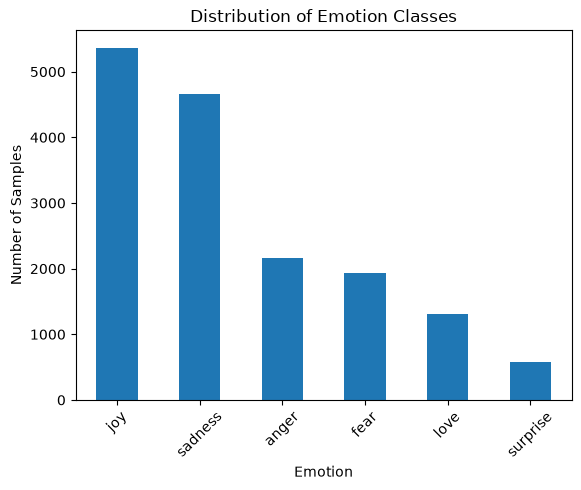

In [13]:
# Plotting the distribution of emotion classes in the training dataset
train_df["emotion"].value_counts().plot(kind="bar")

plt.title("Distribution of Emotion Classes")
plt.xlabel("Emotion")
plt.ylabel("Number of Samples")
plt.xticks(rotation=45)
plt.show()

In [14]:
# Checking for duplicate text entries in the training dataset
train_df["text"].duplicated().sum()

np.int64(31)

In [15]:
# Identifying and displaying the duplicate text entries in the training dataset
duplicates = train_df[train_df["text"].duplicated(keep=False)]

duplicates.sort_values("text").head(20)

,text,label,emotion
3508,i am not amazing or great at photography but i...,1,joy
8246,i am not amazing or great at photography but i...,2,love
5277,i began to feel accepted by gaia on her own terms,2,love
15705,i began to feel accepted by gaia on her own terms,1,joy
8804,i bet taylor swift basks in the knowledge that...,4,fear
15572,i bet taylor swift basks in the knowledge that...,3,anger
11013,i cant escape the tears of sadness and just tr...,2,love
12892,i cant escape the tears of sadness and just tr...,1,joy
13653,i could feel myself hit this strange foggy wall,4,fear
14314,i could feel myself hit this strange foggy wall,5,surprise


In [16]:
# Identifying duplicated texts associated with different labels
conflicting_labels = (
    train_df.groupby("text")["label"]
    .nunique()
)

conflicting_texts = conflicting_labels[conflicting_labels > 1]

print("Number of texts with conflicting labels:", len(conflicting_texts))

Number of texts with conflicting labels: 30


In [17]:
train_df[
    train_df["text"].isin(conflicting_texts.index)
].sort_values("text")

,text,label,emotion
3508,i am not amazing or great at photography but i...,1,joy
8246,i am not amazing or great at photography but i...,2,love
5277,i began to feel accepted by gaia on her own terms,2,love
15705,i began to feel accepted by gaia on her own terms,1,joy
8804,i bet taylor swift basks in the knowledge that...,4,fear
15572,i bet taylor swift basks in the knowledge that...,3,anger
11013,i cant escape the tears of sadness and just tr...,2,love
12892,i cant escape the tears of sadness and just tr...,1,joy
13653,i could feel myself hit this strange foggy wall,4,fear
14314,i could feel myself hit this strange foggy wall,5,surprise


### Cleaning duplicated and conflicting samples

During dataset exploration, some identical text samples were found to be associated with different emotion labels.

These samples introduce label noise because the same input text should not correspond to multiple target classes in this classification task.

Therefore, texts with conflicting labels are removed. Remaining exact duplicates are also removed to avoid giving duplicated samples more importance during model training.

In [18]:
# Number of rows before cleaning
print("Number of training samples before cleaning:", len(train_df))

# Remove all texts associated with conflicting labels
train_df = train_df[
    ~train_df["text"].isin(conflicting_texts.index)
].copy()

# Remove remaining duplicated texts
train_df = train_df.drop_duplicates(subset="text").reset_index(drop=True)

print("Number of training samples after cleaning:", len(train_df))

Number of training samples before cleaning: 16000
Number of training samples after cleaning: 15939


In [19]:
# Checking for duplicate text entries in the training dataset again to make sure we didn't forget any
train_df["text"].duplicated().sum()

np.int64(0)

In [20]:
train_df.shape

(15939, 3)

### Checking for data leakage between dataset splits

To ensure a reliable evaluation, the training, validation, and test sets are checked for overlapping text samples.

If the same text appears in both the training set and an evaluation set, the model may have already seen the sample during training, which could artificially improve its performance.

In [21]:
# Convert the text columns into sets for easier comparison
train_texts = set(train_df["text"])
validation_texts = set(validation_df["text"])
test_texts = set(test_df["text"])

# Find overlaps between the different dataset splits
train_validation_overlap = train_texts.intersection(validation_texts)
train_test_overlap = train_texts.intersection(test_texts)
validation_test_overlap = validation_texts.intersection(test_texts)

print("Train / Validation overlap:", len(train_validation_overlap))
print("Train / Test overlap:", len(train_test_overlap))
print("Validation / Test overlap:", len(validation_test_overlap))

Train / Validation overlap: 5
Train / Test overlap: 11
Validation / Test overlap: 3


In [22]:
# Display texts shared between train and validation
validation_df[
    validation_df["text"].isin(train_validation_overlap)
][["text", "label", "emotion"]]

,text,label,emotion
60,i miss our talks our cuddling our kissing and ...,2,love
466,i feel so blessed to be a part of your days,1,joy
478,i honestly feel at heart we should be faithful...,2,love
1626,i feel completely blessed to be a part of this...,1,joy
1672,i feel that being faithful isnt enough in your...,2,love


In [23]:
# Display texts shared between train and test
test_df[
    test_df["text"].isin(train_test_overlap)
][["text", "label", "emotion"]]

,text,label,emotion
262,i realized what i am passionate about helping ...,1,joy
265,i feel so blessed and honored that we get to b...,2,love
353,i could feel his breath on me and smell the sw...,1,joy
415,i loved the feeling i got during an amazing sl...,1,joy
502,i am feeling stressed and more than a bit anxious,3,anger
586,i found myself feeling inhibited and shushing ...,0,sadness
917,i feel the need to pimp this since raini my be...,1,joy
959,i feel cared for and accepted,2,love
1026,i have not conducted a survey but it is quite ...,0,sadness
1275,i feel so weird and scattered with all wonders...,5,surprise


In [24]:
print(
    "Duplicate texts in validation:",
    validation_df["text"].duplicated().sum()
)

print(
    "Duplicate texts in test:",
    test_df["text"].duplicated().sum()
)

Duplicate texts in validation: 2
Duplicate texts in test: 0


In [25]:
# Identify validation texts associated with more than one label
validation_conflicts = (
    validation_df.groupby("text")["label"]
    .nunique()
)

validation_conflicting_texts = validation_conflicts[
    validation_conflicts > 1
].index

print(
    "Number of validation texts with conflicting labels:",
    len(validation_conflicting_texts)
)

Number of validation texts with conflicting labels: 2


In [26]:
# Remove ambiguous texts from the validation set
validation_df = validation_df[
    ~validation_df["text"].isin(validation_conflicting_texts)
].copy()

# Remove texts from validation that already appear in the training set
validation_df = validation_df[
    ~validation_df["text"].isin(train_df["text"])
].copy()

# Remove remaining internal duplicates from validation
validation_df = (
    validation_df
    .drop_duplicates(subset="text")
    .reset_index(drop=True)
)

In [27]:
# Remove test samples that already appear in the training set
test_df = test_df[
    ~test_df["text"].isin(train_df["text"])
].copy()

# Remove test samples that also appear in the cleaned validation set
test_df = test_df[
    ~test_df["text"].isin(validation_df["text"])
].copy()

# Reset the index
test_df = test_df.reset_index(drop=True)

In [28]:
print("Final training size:", train_df.shape)
print("Final validation size:", validation_df.shape)
print("Final test size:", test_df.shape)

print()

print(
    "Train / Validation overlap:",
    len(set(train_df["text"]).intersection(set(validation_df["text"])))
)

print(
    "Train / Test overlap:",
    len(set(train_df["text"]).intersection(set(test_df["text"])))
)

print(
    "Validation / Test overlap:",
    len(set(validation_df["text"]).intersection(set(test_df["text"])))
)

print()

print(
    "Duplicates in train:",
    train_df["text"].duplicated().sum()
)

print(
    "Duplicates in validation:",
    validation_df["text"].duplicated().sum()
)

print(
    "Duplicates in test:",
    test_df["text"].duplicated().sum()
)

Final training size: (15939, 3)
Final validation size: (1991, 3)
Final test size: (1986, 3)

Train / Validation overlap: 0
Train / Test overlap: 0
Validation / Test overlap: 0

Duplicates in train: 0
Duplicates in validation: 0
Duplicates in test: 0


## 4. Text Preprocessing

Before converting the text into numerical representations, the text data is cleaned and normalized.

The preprocessing applied in this study includes:
- converting text to lowercase,
- removing URLs,
- removing user mentions,
- removing unnecessary special characters,
- removing extra whitespace.

Stopwords are intentionally preserved because some of them, especially negation words such as
"not", "no", and "never", may carry important information for emotion classification.

In [29]:
import re

In [30]:
def clean_text(text):
    # Convert text to lowercase
    text = text.lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove user mentions such as @username
    text = re.sub(r"@\w+", "", text)

    # Keep letters, apostrophes and spaces
    text = re.sub(r"[^a-z'\s]", " ", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [31]:
example_text = "I am REALLY happy!!! Visit https://example.com @john"
print("Original:", example_text)
print("Cleaned :", clean_text(example_text))

Original: I am REALLY happy!!! Visit https://example.com @john
Cleaned : i am really happy visit


In [32]:
# Apply the cleaning function to the text columns in all datasets
train_df["clean_text"] = train_df["text"].apply(clean_text)
validation_df["clean_text"] = validation_df["text"].apply(clean_text)
test_df["clean_text"] = test_df["text"].apply(clean_text)

In [33]:
train_df[["text", "clean_text"]].head(10)

,text,clean_text
0,i didnt feel humiliated,i didnt feel humiliated
1,i can go from feeling so hopeless to so damned...,i can go from feeling so hopeless to so damned...
2,im grabbing a minute to post i feel greedy wrong,im grabbing a minute to post i feel greedy wrong
3,i am ever feeling nostalgic about the fireplac...,i am ever feeling nostalgic about the fireplac...
4,i am feeling grouchy,i am feeling grouchy
5,ive been feeling a little burdened lately wasn...,ive been feeling a little burdened lately wasn...
6,ive been taking or milligrams or times recomme...,ive been taking or milligrams or times recomme...
7,i feel as confused about life as a teenager or...,i feel as confused about life as a teenager or...
8,i have been with petronas for years i feel tha...,i have been with petronas for years i feel tha...
9,i feel romantic too,i feel romantic too


In [34]:
# Check for empty texts after cleaning
print("Empty texts in train:", (train_df["clean_text"] == "").sum())
print("Empty texts in validation:", (validation_df["clean_text"] == "").sum())
print("Empty texts in test:", (test_df["clean_text"] == "").sum())

Empty texts in train: 0
Empty texts in validation: 0
Empty texts in test: 0


## 5. Tokenization

Tokenization consists of splitting a text into smaller units called tokens.

In this project, each cleaned sentence is split into individual words.
For example:

"I am feeling very happy today"

becomes:

["i", "am", "feeling", "very", "happy", "today"]

This representation makes it possible to analyze the vocabulary and prepares the text for numerical vectorization.

In [35]:
# Tokenize the cleaned text into individual words
train_df["tokens"] = train_df["clean_text"].apply(lambda text: text.split())
validation_df["tokens"] = validation_df["clean_text"].apply(lambda text: text.split())
test_df["tokens"] = test_df["clean_text"].apply(lambda text: text.split())

In [36]:
train_df[["clean_text", "tokens"]].head()

,clean_text,tokens
0,i didnt feel humiliated,"[i, didnt, feel, humiliated]"
1,i can go from feeling so hopeless to so damned...,"[i, can, go, from, feeling, so, hopeless, to, ..."
2,im grabbing a minute to post i feel greedy wrong,"[im, grabbing, a, minute, to, post, i, feel, g..."
3,i am ever feeling nostalgic about the fireplac...,"[i, am, ever, feeling, nostalgic, about, the, ..."
4,i am feeling grouchy,"[i, am, feeling, grouchy]"


In [37]:
# Number of tokens in each training sample
train_df["text_length"] = train_df["tokens"].apply(len)

train_df["text_length"].describe()

count    15939.000000
mean        19.176234
std         10.994506
min          2.000000
25%         11.000000
50%         17.000000
75%         25.000000
max         66.000000
Name: text_length, dtype: float64

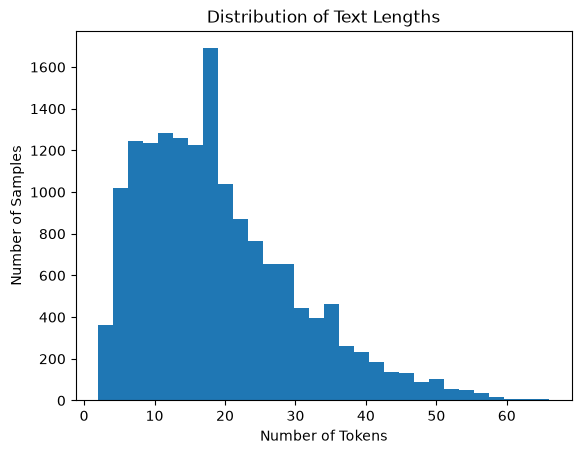

In [38]:
# Plotting the distribution of text lengths in the training dataset
plt.hist(train_df["text_length"], bins=30)

plt.title("Distribution of Text Lengths")
plt.xlabel("Number of Tokens")
plt.ylabel("Number of Samples")
plt.show()

## 6. Text Vectorization with TF-IDF

Machine learning models cannot directly process raw text. Therefore, the cleaned text must be converted into numerical features.

In this project, **TF-IDF (Term Frequency - Inverse Document Frequency)** is used to represent each text as a numerical vector.

TF-IDF gives higher importance to words that are frequent in a specific text but less common across the entire dataset. This helps emphasize words that may be useful for distinguishing between different emotions.

Both single words (unigrams) and pairs of consecutive words (bigrams) are considered.

In [39]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [40]:
# Initialize the TF-IDF vectorizer with a maximum of 20,000 features and considering unigrams and bigrams
tfidf = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1, 2)
)

In [41]:
# Fit the TF-IDF vectorizer on the training data and transform the text data into TF-IDF features

X_train = tfidf.fit_transform(train_df["clean_text"])
X_validation = tfidf.transform(validation_df["clean_text"])
X_test = tfidf.transform(test_df["clean_text"])

## 7. Preparing the Target Labels

The input texts have now been converted into numerical TF-IDF vectors.

The corresponding emotion labels are stored separately as target variables (`y`) for training, validation, and testing.

In [42]:
# Target labels
y_train = train_df["label"]
y_validation = validation_df["label"]
y_test = test_df["label"]

In [43]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("X_validation shape:", X_validation.shape)
print("y_validation shape:", y_validation.shape)

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (15939, 20000)
y_train shape: (15939,)
X_validation shape: (1991, 20000)
y_validation shape: (1991,)
X_test shape: (1986, 20000)
y_test shape: (1986,)


## 8. Machine Learning Model – Linear SVM

A Linear Support Vector Machine (SVM) is used as the first classification model.

Linear SVM is well suited for text classification because TF-IDF representations are
high-dimensional and sparse. The model attempts to find decision boundaries that best
separate the different emotion classes.

This model will serve as a baseline and may later be compared with a more advanced
Deep Learning model.

In [44]:
from sklearn.svm import LinearSVC

In [45]:
# Create the Linear SVM classifier
svm_model = LinearSVC()

In [46]:
# Train the model using the TF-IDF representations
svm_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [47]:
# Predict the emotion labels for the validation set
y_validation_pred = svm_model.predict(X_validation)

In [48]:
from sklearn.metrics import accuracy_score, classification_report

In [49]:
# Compute the validation accuracy
validation_accuracy = accuracy_score(y_validation, y_validation_pred)

print("Validation Accuracy:", validation_accuracy)

Validation Accuracy: 0.8960321446509292


In [50]:
print(
    classification_report(
        y_validation,
        y_validation_pred,
        target_names=label_names
    )
)

              precision    recall  f1-score   support

     sadness       0.90      0.93      0.92       550
         joy       0.90      0.94      0.92       701
        love       0.82      0.80      0.81       174
       anger       0.93      0.89      0.91       274
        fear       0.92      0.82      0.86       211
    surprise       0.80      0.74      0.77        81

    accuracy                           0.90      1991
   macro avg       0.88      0.85      0.86      1991
weighted avg       0.90      0.90      0.90      1991



### Validation Results Interpretation

The Linear SVM model achieved a validation accuracy of approximately **89.6%**.

The model performs particularly well on the `sadness`, `joy`, and `anger` classes, with F1-scores above 0.90.

Lower performance is observed for the `love` and especially `surprise` classes. One possible explanation is the class imbalance observed earlier in the dataset: these classes contain fewer training examples, which may make them more difficult for the model to learn.

The macro-average F1-score is lower than the weighted-average F1-score, which also suggests that performance is not perfectly balanced across all emotion classes.

In [51]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

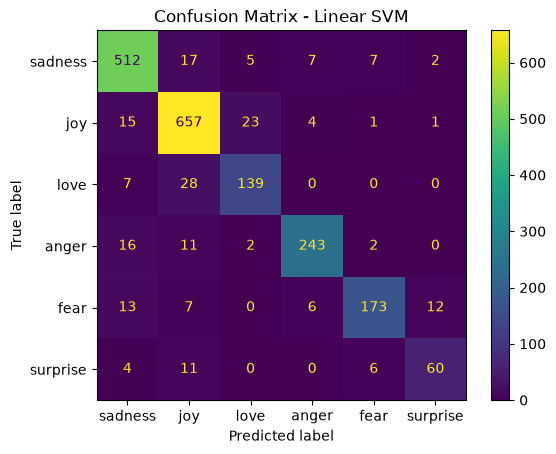

In [52]:
# Compute the confusion matrix
cm = confusion_matrix(y_validation, y_validation_pred)

# Display the confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=label_names
)

disp.plot()
plt.title("Confusion Matrix - Linear SVM")
plt.show()

### Confusion Matrix Interpretation

The confusion matrix shows that the Linear SVM correctly classifies the majority of the validation samples.

The largest confusion occurs between **love and joy**. In particular, 28 `love` samples were predicted as `joy`, while 23 `joy` samples were predicted as `love`. This may be explained by the semantic similarity between these two emotions and the vocabulary commonly used to express them.

Some confusion is also observed between **fear and surprise**, with 12 `fear` samples predicted as `surprise` and 6 `surprise` samples predicted as `fear`.

The `sadness`, `joy`, and `anger` classes are generally well recognized, while `love` and `surprise` remain more difficult to classify. This is consistent with the previous classification report and may partly be explained by the class imbalance observed in the dataset.

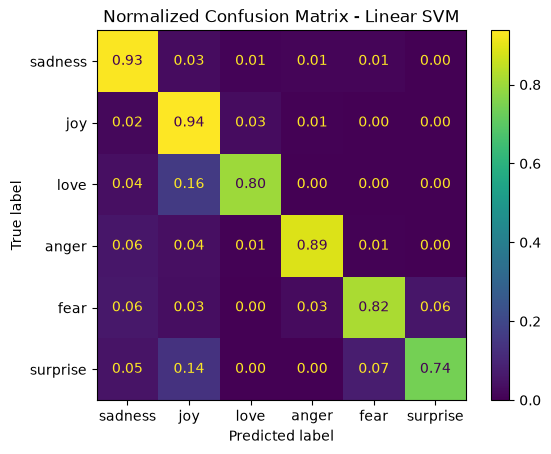

In [53]:
# Normalized confusion matrix
cm_normalized = confusion_matrix(
    y_validation,
    y_validation_pred,
    normalize="true"
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=label_names
)

disp.plot(values_format=".2f")
plt.title("Normalized Confusion Matrix - Linear SVM")
plt.show()

In [54]:
# Create a DataFrame containing validation predictions

pd.set_option("display.max_colwidth", None)

error_analysis = validation_df[
    ["text", "emotion", "label"]
].copy()

error_analysis["predicted_label"] = y_validation_pred
error_analysis["predicted_emotion"] = [
    label_names[label] for label in y_validation_pred
]

# Keep only incorrect predictions
errors = error_analysis[
    error_analysis["label"] != error_analysis["predicted_label"]
]

errors[["text", "emotion", "predicted_emotion"]].head(20)

,text,emotion,predicted_emotion
26,i don t know if anybody will ever be able to feel how i feel or at least relate when everything is lost you find yourself missing and longing for it them,sadness,love
27,i feel as if i am the beloved preparing herself for the wedding,joy,love
45,i cant sleep i switch on music if i need to wake up i switch on music if i feel morose music it is that comes to my rescue whenever i feel ecstatic the tunes are by my side if i want to meet my wild side hail music,sadness,joy
48,i see the starlight caress your hair no more feel the tender kisses we used to share i close my eyes and clearly my heart remembers a thousand good byes could never put out the embers,love,joy
53,i everyone this will be a bit of a brief post as ive got a stinking cold at the moment and am feeling very very crappy but i have another page done on,sadness,anger
55,i didn t feel accepted,joy,love
67,i feel very strange today,fear,surprise
77,i feel like ive been punished and i can turn it around and dont have anything to be afraid of,sadness,fear
82,i feel stressed or my family is being negative work is my getaway and every stressor goes away because of the kids,sadness,anger
114,i went from feeling helpless to powerful,sadness,fear


### Error Analysis

The analysis of misclassified validation samples shows that several errors occur on
semantically ambiguous texts.

For example, the sentence *"I feel very strange today"* is labeled as `fear` but predicted
as `surprise`. Without additional context, both emotions may be plausible.

Some errors may also be influenced by strongly emotion-related words. For instance, a sentence
containing the word *"surprised"* was predicted as `surprise` even though its true label was
`sadness`.

This illustrates one limitation of the TF-IDF representation: it mainly relies on word and
n-gram importance but has a limited ability to understand the complete semantic context of a
sentence.

In addition, some dataset labels appear ambiguous, which may also contribute to classification
errors.

In [55]:
# Predict the emotion labels for the test set
y_test_pred = svm_model.predict(X_test)

In [56]:
# Compute final test accuracy
test_accuracy = accuracy_score(y_test, y_test_pred)

print("Test Accuracy:", test_accuracy)

Test Accuracy: 0.8826787512588117


In [57]:
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=label_names
    )
)

              precision    recall  f1-score   support

     sadness       0.90      0.93      0.92       579
         joy       0.89      0.94      0.91       688
        love       0.81      0.72      0.76       156
       anger       0.89      0.88      0.88       274
        fear       0.89      0.80      0.84       224
    surprise       0.69      0.57      0.62        65

    accuracy                           0.88      1986
   macro avg       0.84      0.81      0.82      1986
weighted avg       0.88      0.88      0.88      1986



### Final Test Results

The Linear SVM model achieved a final test accuracy of approximately **88.3%**.

The model performs particularly well on the `sadness` and `joy` classes, with F1-scores above 0.90.

The lowest performances are observed for `love` and especially `surprise`.
The `surprise` class obtains an F1-score of 0.62, which may partly be explained by its lower representation in the training dataset.

The macro-average F1-score is 0.82, while the weighted-average F1-score is 0.88.
This difference indicates that the model performs better on the most represented classes than on the minority classes.

Overall, the results show that TF-IDF combined with a Linear SVM provides a strong baseline for emotion classification.

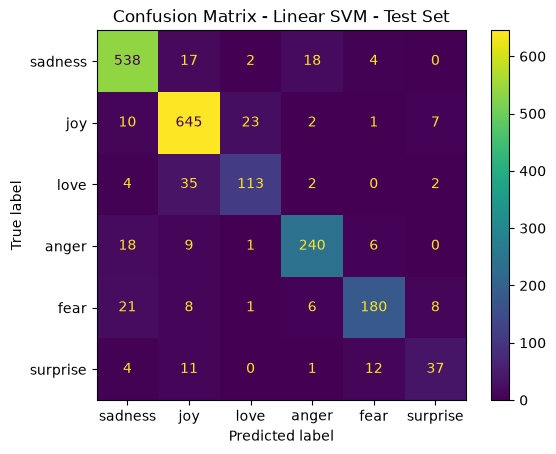

In [58]:
# Compute the test confusion matrix
test_cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=test_cm,
    display_labels=label_names
)

disp.plot()
plt.title("Confusion Matrix - Linear SVM - Test Set")
plt.show()

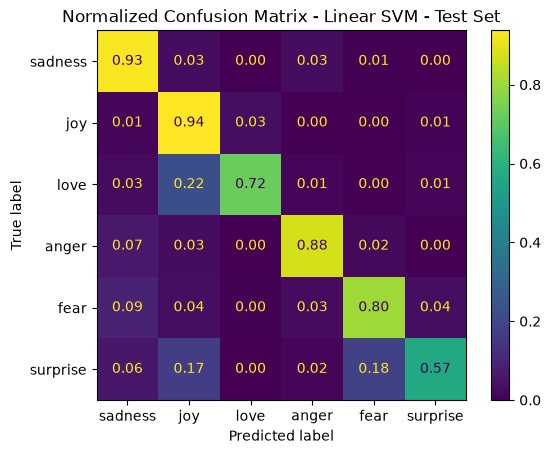

In [59]:
test_cm_normalized = confusion_matrix(
    y_test,
    y_test_pred,
    normalize="true"
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=test_cm_normalized,
    display_labels=label_names
)

disp.plot(values_format=".2f")
plt.title("Normalized Confusion Matrix - Linear SVM - Test Set")
plt.show()

# 9. Deep Learning Model – DistilBERT Transformer

As a second approach, a Transformer-based model is fine-tuned for emotion classification.

The selected model is **DistilBERT**, a lighter and faster version of BERT that retains
contextual language understanding while requiring fewer computational resources.

Unlike the previous TF-IDF + Linear SVM approach, DistilBERT does not represent words only
according to their frequency. Instead, it generates contextual representations, allowing the
meaning of a word to depend on the surrounding words.

The objective is to compare this contextual Deep Learning approach with the previous
Machine Learning baseline.

In [60]:
%pip install torch --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [61]:
%pip install transformers accelerate

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [62]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("Device used:", device)

if torch.cuda.is_available():
    print("CUDA version used by PyTorch:", torch.version.cuda)
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )
else:
    print("No CUDA-compatible GPU detected. The model will run on CPU.")

PyTorch version: 2.11.0+cu128
CUDA available: True
Device used: cuda
CUDA version used by PyTorch: 12.8
GPU: NVIDIA GeForce RTX 5070 Ti Laptop GPU
GPU memory: 11.91 GB


In [63]:
from datasets import Dataset

# Convert the cleaned Pandas splits back into Hugging Face datasets
bert_train_dataset = Dataset.from_pandas(
    train_df[["text", "label"]],
    preserve_index=False
)

bert_validation_dataset = Dataset.from_pandas(
    validation_df[["text", "label"]],
    preserve_index=False
)

bert_test_dataset = Dataset.from_pandas(
    test_df[["text", "label"]],
    preserve_index=False
)

In [64]:
bert_train_dataset

Dataset({
    features: ['text', 'label'],
    num_rows: 15939
})

In [65]:
from transformers import AutoTokenizer

model_name = "distilbert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

In [66]:
example_text = "I am not feeling very happy today."

print(tokenizer.tokenize(example_text))

['i', 'am', 'not', 'feeling', 'very', 'happy', 'today', '.']


In [67]:
def tokenize_function(examples):
    return tokenizer(
        examples["text"],
        truncation=True,
        max_length=128
    )

In [68]:
bert_train_tokenized = bert_train_dataset.map(
    tokenize_function,
    batched=True
)

bert_validation_tokenized = bert_validation_dataset.map(
    tokenize_function,
    batched=True
)

bert_test_tokenized = bert_test_dataset.map(
    tokenize_function,
    batched=True
)

Map: 100%|██████████| 1986/1986 [00:00<00:00, 28547.35 examples/s]


In [69]:
bert_train_tokenized[0]

{'text': 'i didnt feel humiliated',
 'label': 0,
 'input_ids': [101, 1045, 2134, 2102, 2514, 26608, 102],
 'token_type_ids': [0, 0, 0, 0, 0, 0, 0],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1]}

In [70]:
from transformers import AutoModelForSequenceClassification

In [71]:
id2label = {
    i: label_names[i]
    for i in range(len(label_names))
}

label2id = {
    label_names[i]: i
    for i in range(len(label_names))
}

print(id2label)

{0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [72]:
bert_model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=6,
    id2label=id2label,
    label2id=label2id
)

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 560.65it/s]
[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## 9.5 Fine-Tuning Configuration

The pretrained DistilBERT model is now fine-tuned on the emotion classification dataset.

During fine-tuning, the pretrained language representations are adapted to the specific task
of predicting six emotion classes.

The model is trained for three epochs using a learning rate of 2e-5 and mixed-precision
training on the GPU.

In [73]:
# Define the data collator for padding the sequences to the same length

from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer
)

In [74]:
# Define the compute_metrics function to calculate accuracy, precision, recall, and F1 score

from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import numpy as np

def compute_metrics(eval_pred):
    logits, labels = eval_pred

    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_score(labels, predictions)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="macro",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision_macro": precision,
        "recall_macro": recall,
        "f1_macro": f1
    }

In [75]:
from transformers import TrainingArguments

In [76]:
training_args = TrainingArguments(
    output_dir="./results/distilbert_emotion",

    learning_rate=2e-5,

    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,

    num_train_epochs=3,

    weight_decay=0.01,

    eval_strategy="epoch",
    save_strategy="epoch",

    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,

    fp16=torch.cuda.is_available(),

    save_total_limit=2,

    logging_steps=50,

    report_to="none",

    seed=42
)

In [77]:
# Initialize the trainer

from transformers import Trainer

trainer = Trainer(
    model=bert_model,
    args=training_args,

    train_dataset=bert_train_tokenized,
    eval_dataset=bert_validation_tokenized,

    processing_class=tokenizer,
    data_collator=data_collator,

    compute_metrics=compute_metrics
)

In [78]:
print("Model device:", trainer.model.device)

Model device: cuda:0


In [79]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,0.250071,0.232785,0.923656,0.918641,0.882429,0.895820
2,0.142229,0.150970,0.935208,0.898677,0.915105,0.906518
3,0.107872,0.143913,0.938222,0.908355,0.913199,0.910443


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.65it/s]


TrainOutput(global_step=1497, training_loss=0.28623422910630425, metrics={'train_runtime': 74.1815, 'train_samples_per_second': 644.595, 'train_steps_per_second': 20.18, 'total_flos': 643240818597816.0, 'train_loss': 0.28623422910630425, 'epoch': 3.0})

## 9.6 Final Evaluation of DistilBERT

After fine-tuning and model selection using the validation set, the final DistilBERT model is evaluated on the unseen test set.

The test set was not used during training or hyperparameter selection, allowing an unbiased comparison with the Linear SVM baseline.

In [80]:
# Evaluate the final DistilBERT model on the test set
bert_test_results = trainer.evaluate(bert_test_tokenized)

bert_test_results

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro
0.107872,0.163046,3,0.929003,0.899030,0.892325,0.894086


{'eval_loss': 0.16304588317871094,
 'eval_accuracy': 0.9290030211480362,
 'eval_precision_macro': 0.8990301808593179,
 'eval_recall_macro': 0.892324956489113,
 'eval_f1_macro': 0.89408631462597}

In [81]:
# Generate predictions on the test set
bert_test_output = trainer.predict(bert_test_tokenized)

bert_test_logits = bert_test_output.predictions

bert_test_pred = np.argmax(
    bert_test_logits,
    axis=-1
)

In [82]:
print(
    classification_report(
        y_test,
        bert_test_pred,
        target_names=label_names
    )
)

              precision    recall  f1-score   support

     sadness       0.96      0.96      0.96       579
         joy       0.96      0.93      0.95       688
        love       0.80      0.88      0.84       156
       anger       0.91      0.93      0.92       274
        fear       0.89      0.92      0.91       224
    surprise       0.87      0.72      0.79        65

    accuracy                           0.93      1986
   macro avg       0.90      0.89      0.89      1986
weighted avg       0.93      0.93      0.93      1986



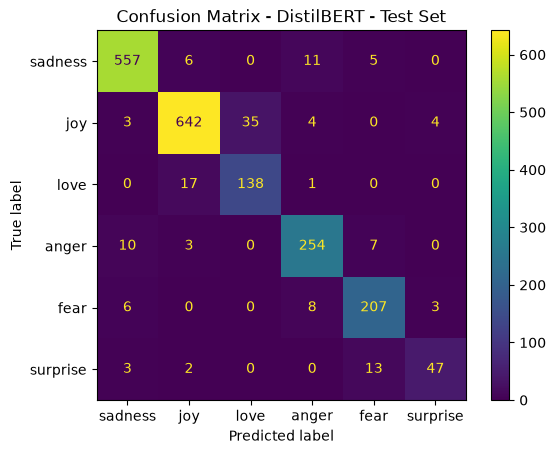

In [83]:
bert_test_cm = confusion_matrix(
    y_test,
    bert_test_pred
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=bert_test_cm,
    display_labels=label_names
)

disp.plot()
plt.title("Confusion Matrix - DistilBERT - Test Set")
plt.show()

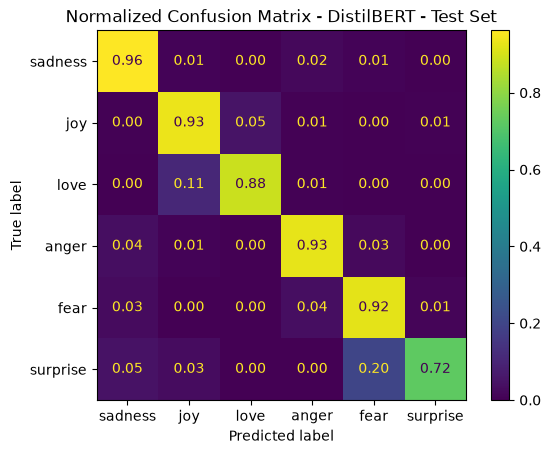

In [84]:
bert_test_cm_normalized = confusion_matrix(
    y_test,
    bert_test_pred,
    normalize="true"
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=bert_test_cm_normalized,
    display_labels=label_names
)

disp.plot(values_format=".2f")
plt.title("Normalized Confusion Matrix - DistilBERT - Test Set")
plt.show()

# 10. Model Comparison

Two different approaches were implemented for the emotion classification task:

1. **TF-IDF + Linear SVM**, a classical machine learning approach.
2. **Fine-tuned DistilBERT**, a Transformer-based deep learning approach.

The objective of this comparison is to evaluate whether contextual language representations
provided by DistilBERT improve emotion classification compared with the frequency-based
TF-IDF representation.

In [85]:
from sklearn.metrics import f1_score

svm_macro_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro"
)

bert_macro_f1 = f1_score(
    y_test,
    bert_test_pred,
    average="macro"
)

comparison_df = pd.DataFrame({
    "Model": [
        "TF-IDF + Linear SVM",
        "DistilBERT"
    ],
    "Test Accuracy": [
        accuracy_score(y_test, y_test_pred),
        accuracy_score(y_test, bert_test_pred)
    ],
    "Macro F1": [
        svm_macro_f1,
        bert_macro_f1
    ]
})

comparison_df

,Model,Test Accuracy,Macro F1
0,TF-IDF + Linear SVM,0.882679,0.823651
1,DistilBERT,0.929003,0.894086


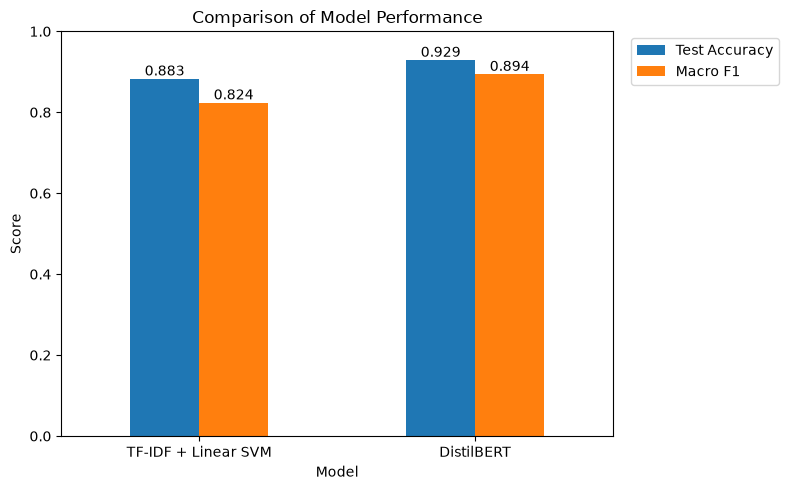

In [86]:
ax = comparison_df.set_index("Model")[["Test Accuracy", "Macro F1"]].plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Comparison of Model Performance")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(
    loc="upper left",
    bbox_to_anchor=(1.02, 1)
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f")

plt.tight_layout()
plt.show()

### Model Comparison Interpretation

DistilBERT outperformed the TF-IDF + Linear SVM baseline on both evaluation metrics.

The Linear SVM achieved a test accuracy of approximately **88.3%**, while DistilBERT reached approximately **93.2%**.

The macro F1-score also increased from approximately **0.824** with the Linear SVM to **0.898** with DistilBERT. This improvement shows that DistilBERT performs better not only overall, but also across the different emotion classes, including the less represented ones.

The main reason for this improvement is the way the two models represent language.

TF-IDF mainly relies on the frequency and importance of individual words and short sequences of words. As a result, it has limited ability to understand the complete semantic context of a sentence.

DistilBERT, on the other hand, produces contextual representations. The representation of each token depends on the surrounding words, which allows the model to better capture the meaning of the sentence and distinguish between semantically similar emotions.

However, DistilBERT requires more computational resources and a longer training process than the Linear SVM. Therefore, the choice between the two approaches depends on the trade-off between predictive performance, computational cost, and model complexity.

Overall, DistilBERT is the best-performing model for this emotion classification task.

## Brief Literature Review

Natural Language Processing (NLP) combines techniques from linguistics, machine learning, and deep learning to enable computers to process and analyze human language.

### Tokenization

Tokenization consists of splitting text into smaller units called tokens. These units can be words, characters, or subwords.

Traditional NLP approaches often rely on word-level tokenization. Modern Transformer models such as BERT and DistilBERT use subword tokenization, which allows uncommon or unknown words to be decomposed into smaller known units.

### Text Vectorization

Machine learning algorithms cannot directly process raw text. Therefore, textual data must be converted into numerical representations.

One common technique is **TF-IDF (Term Frequency - Inverse Document Frequency)**. TF-IDF assigns higher importance to terms that are frequent in a specific document but less common across the full collection of documents.

TF-IDF produces sparse numerical vectors and is especially suitable for traditional machine learning classifiers such as Support Vector Machines.

### Word Embeddings and Contextual Representations

Word embeddings represent words as dense numerical vectors. Techniques such as Word2Vec and GloVe aim to place semantically similar words close to each other in the vector space.

However, traditional word embeddings generally assign one fixed vector to each word, regardless of context.

Transformer-based models such as BERT introduced contextual representations, where the representation of a word depends on the other words in the sentence. This is particularly useful for tasks such as sentiment and emotion classification.

### Machine Learning for Text Classification

Traditional machine learning models such as Naive Bayes, Logistic Regression, and Support Vector Machines are widely used for text classification.

Linear Support Vector Machines are particularly effective with high-dimensional sparse text representations such as TF-IDF.

### Deep Learning and Transformers

Deep learning models can learn more complex representations of language. Earlier NLP approaches included Recurrent Neural Networks (RNNs) and Convolutional Neural Networks (CNNs).

Transformer models introduced the self-attention mechanism, which allows the model to capture relationships between words across a sentence.

BERT is a pretrained Transformer model that can be fine-tuned for downstream NLP tasks. DistilBERT is a lighter and faster version of BERT designed to preserve much of its language understanding capability while requiring fewer computational resources.

In this project, a traditional **TF-IDF + Linear SVM** approach and a **fine-tuned DistilBERT** model are implemented and compared.